## 2. Clustering implementation

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\Viki\Guvi DS\Capstone Projects\Amazon Music Clustering\data\single_genre_artists.csv")

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078,['vintage chanson'],Mistinguett,22


In [13]:
import pandas as pd

df_1 = pd.read_csv(r"D:\Viki\Guvi DS\Capstone Projects\Amazon Music Clustering\notebook\non_featured_data.csv")

print("Data loaded successfully!")
df_1.head()

Data loaded successfully!


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078,['vintage chanson'],Mistinguett,22


In [3]:
import numpy as np

X_scaled = np.load("X_scaled.npy")

print("Loaded successfully!")
print(X_scaled.shape)

Loaded successfully!
(95837, 10)


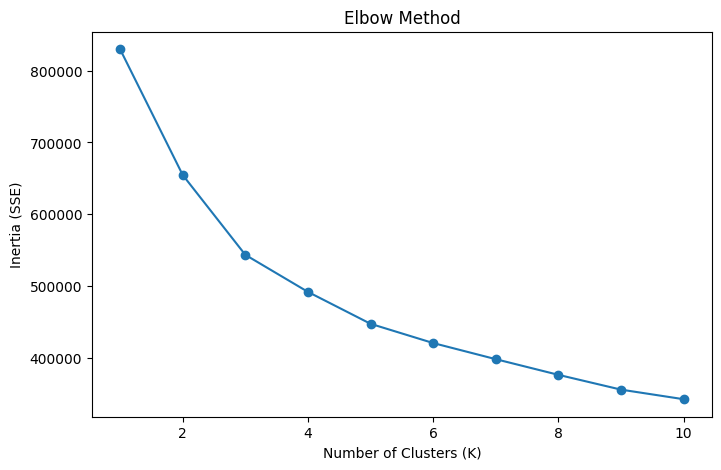

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k = None
highest_score = -1  

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print(f"K={k}, Silhouette Score={score}")
    
    # Track best K
    if score > highest_score:
        highest_score = score
        best_k = k

print("\nBest K (No of Clusters):", best_k)
print("Highest Silhouette Score:", highest_score)

K=2, Silhouette Score=0.2119774179359552
K=3, Silhouette Score=0.25141908960139914
K=4, Silhouette Score=0.18742994349705394
K=5, Silhouette Score=0.1980392577151205
K=6, Silhouette Score=0.1975400028600479

Best K (No of Clusters): 3
Highest Silhouette Score: 0.25141908960139914


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

best_k = None
lowest_dbi = float('inf')  

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_k = kmeans.fit_predict(X_scaled)
    
    dbi = davies_bouldin_score(X_scaled, labels_k)
    
    print(f"K={k}, DBI={dbi}")
    
    # Track best K
    if dbi < lowest_dbi:
        lowest_dbi = dbi
        best_k = k

print("\nBest K (No of Clusters):", best_k)
print("Lowest DBI:", lowest_dbi)

K=2, DBI=1.8468110839141174
K=3, DBI=1.4941635288752373
K=4, DBI=1.7401570403273257
K=5, DBI=1.6425894250448263
K=6, DBI=1.6055146626072092

Best K (No of Clusters): 3
Lowest DBI: 1.4941635288752373


In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

In [10]:
import numpy as np
np.save("clusters.npy", labels)

In [15]:
df.shape

(95837, 11)

In [16]:
df_1.shape

(95837, 23)

In [17]:
len(df_1) == len(labels)

True